In [1]:
!pip install -q medmnist
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Experiment 7: Denoising a Signal using Deep Learning (Autoencoder-based)
**Aim:** To remove noise from a 1D signal using a Conv1D autoencoder.

MSE (noisy vs clean):    0.09025843508133877
MSE (denoised vs clean): 0.021802128588276706


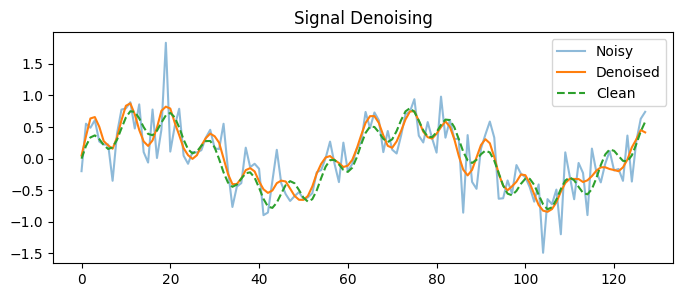

In [2]:
n_samples, length = 3000, 128
x_axis = np.linspace(0, 1, length)
clean = np.zeros((n_samples, length))
for i in range(n_samples):
    f1, f2 = np.random.uniform(2, 8), np.random.uniform(8, 16)
    a1, a2 = np.random.uniform(0.5, 1), np.random.uniform(0.2, 0.6)
    clean[i] = a1 * np.sin(2 * np.pi * f1 * x_axis) + a2 * np.sin(2 * np.pi * f2 * x_axis)
noisy = clean + 0.3 * np.random.randn(n_samples, length)

clean = clean[..., None]
noisy = noisy[..., None]
n_tr = 2400

dae = models.Sequential([
    layers.Input(shape=(length, 1)),
    layers.Conv1D(16, 5, strides=2, padding='same', activation='relu'),
    layers.Conv1D(8, 5, strides=2, padding='same', activation='relu'),
    layers.Conv1DTranspose(8, 5, strides=2, padding='same', activation='relu'),
    layers.Conv1DTranspose(16, 5, strides=2, padding='same', activation='relu'),
    layers.Conv1D(1, 5, strides=1, padding='same')
])
dae.compile(optimizer='adam', loss='mse')
dae.fit(noisy[:n_tr], clean[:n_tr], epochs=20, batch_size=64, validation_split=0.1, verbose=0)

den = dae.predict(noisy[n_tr:], verbose=0)
print("MSE (noisy vs clean):   ", np.mean((noisy[n_tr:] - clean[n_tr:]) ** 2))
print("MSE (denoised vs clean):", np.mean((den - clean[n_tr:]) ** 2))

plt.figure(figsize=(8, 3))
plt.plot(noisy[n_tr, :, 0], alpha=0.5, label='Noisy')
plt.plot(den[0, :, 0], label='Denoised')
plt.plot(clean[n_tr, :, 0], '--', label='Clean')
plt.legend()
plt.title('Signal Denoising')
plt.show()